# Modeling a Magneto Rheological Damper Device

## Reproducibility

This tutorial was verified with SysIdentPy 0.9.0 on Python 3.12.12, pandas 2.3.3
and scikit-learn 1.7.2. Data loaded from `sysidentpy-data` use an immutable commit
URL. Randomized examples set an explicit seed.

Note: The example shown in this notebook is taken from the companion book [Nonlinear System Identification and Forecasting: Theory and Practice with SysIdentPy](https://sysidentpy.org/book/0-Preface/).

The memory effects between quasi-static input and output make the modeling of hysteretic systems very difficult. Physics-based models are often used to describe the hysteresis loops, but these models usually lack the simplicity and efficiency required in practical applications involving system characterization, identification, and control. As detailed in [Martins, S. A. M. and Aguirre, L. A. - Sufficient conditions for rate-independent hysteresis in autoregressive identified models](https://www.sciencedirect.com/science/article/abs/pii/S0888327015005968), NARX models have proven to be a feasible choice to describe the hysteresis loops. See Chapter 8 for a detailed background. However, even considering the sufficient conditions for rate independent hysteresis representation, classical structure selection algorithms fails to return a model with decent performance and the user needs to set a multi-valued function to ensure the occurrence of the bounding structure $\mathcal{H}$ ([Martins, S. A. M. and Aguirre, L. A. - Sufficient conditions for rate-independent hysteresis in autoregressive identified models](https://www.sciencedirect.com/science/article/abs/pii/S0888327015005968)).

Even though some progress has been made, previous work has been limited to models with a single equilibrium point. The present case study aims to present new prospects in the model structure selection of hysteretic systems regarding the cases where the models have multiple inputs, and it is not restricted concerning the number of equilibrium points. For that, the MetaMSS algorithm will be used to build a model for a magneto-rheological damper (MRD) considering the mentioned sufficient conditions.

### A Brief description of the Bouc-Wen model of magneto-rheological damper device

The data used in this study-case is the Bouc-Wen model ([Bouc, R - Forced Vibrations of a Mechanical System with Hysteresis](https://www.scirp.org/reference/referencespapers?referenceid=726819)), ([Wen, Y. X. - Method for Random Vibration of Hysteretic Systems](https://ascelibrary.org/doi/10.1061/JMCEA3.0002106)) of an MRD whose schematic diagram is shown in the figure below.


![](https://github.com/wilsonrljr/sysidentpy-data/blob/f38f95efb02194bf2ab116d63982305e2ec09213/book/assets/bouc_wen.png?raw=true)
> The model for a magneto-rheological damper proposed by [Spencer, B. F. and Sain, M. K. - Controlling buildings: a new frontier in feedback](https://ieeexplore.ieee.org/document/642972).

The general form of the Bouc-Wen model can be described as ([Spencer, B. F. and Sain, M. K. - Controlling buildings: a new frontier in feedback](https://ieeexplore.ieee.org/document/642972)):

$$
\begin{equation}
\dfrac{dz}{dt} = g\left[x,z,sign\left(\dfrac{dx}{dt}\right)\right]\dfrac{dx}{dt},
\end{equation}
$$

where $z$ is the hysteretic model output, $x$ the input and $g[\cdot]$ a nonlinear function of $x$, $z$ and $sign (dx/dt)$. ([Spencer, B. F. and Sain, M. K. - Controlling buildings: a new frontier in feedback](https://ieeexplore.ieee.org/document/642972)) proposed the following phenomenological model for the aforementioned device:

$$
\begin{aligned}
f&= c_1\dot{\rho}+k_1(x-x_0),\nonumber\\
\dot{\rho}&=\dfrac{1}{c_0+c_1}[\alpha z+c_0\dot{x}+k_0(x-\rho)],\nonumber\\
\dot{z}&=-\gamma|\dot{x}-\dot{\rho}|z|z|^{n-1}-\beta(\dot{x}-\dot{\rho})|z|^n+A(\dot{x}-\dot{\rho}),\nonumber\\
\alpha&=\alpha_a+\alpha_bu_{bw},\nonumber\\
c_1&=c_{1a}+c_{1b}u_{bw},\nonumber\\
c_0&=c_{0a}+c_{0b}u_{bw},\nonumber\\
\dot{u}_{bw}&=-\eta(u_{bw}-E).
\end{aligned}
$$

where $f$ is the damping force, $c_1$ and $c_0$ represent the viscous coefficients, $E$ is the input voltage, $x$ is the displacement and $\dot{x}$ is the velocity of the model. The parameters of the system (see table below) were taken from [Leva, A. and Piroddi, L. - NARX-based technique for the modelling of magneto-rheological damping devices](https://iopscience.iop.org/article/10.1088/0964-1726/11/1/309).

| Parameter  | Value          | Parameter | Value        |
|------------|----------------|-----------|--------------|
| $c_{0_a}$  | $20.2 \, N \, s/cm$  | $\alpha_{a}$  | $44.9 \, N/cm$  |
| $c_{0_b}$  | $2.68 \, N \, s/cm \, V$ | $\alpha_{b}$  | $638 \, N/cm$   |
| $c_{1_a}$  | $350 \, N \, s/cm$   | $\gamma$      | $39.3 \, cm^{-2}$ |
| $c_{1_b}$  | $70.7 \, N \, s/cm \, V$  | $\beta$       | $39.3 \, cm^{-2}$ |
| $k_{0}$    | $15 \, N/cm$    | $n$           | $2$          |
| $k_{1}$    | $5.37 \, N/cm$   | $\eta$       | $251 \, s^{-1}$ |
| $x_{0}$    | $0 \, cm$      | $A$           | $47.2$       |

For this particular study, both displacement and voltage inputs, $x$ and $E$, respectively, were generated by filtering a white Gaussian noise sequence using a Blackman-Harris FIR filter with $6$Hz cutoff frequency. The integration step-size was set to $h = 0.002$, following the procedures described in [Martins, S. A. M. and Aguirre, L. A. - Sufficient conditions for rate-independent hysteresis in autoregressive identified models](https://www.sciencedirect.com/science/article/abs/pii/S0888327015005968). These procedures are for identification purposes only since the inputs of a MRD could have several different characteristics.

The data used in this example is provided by the Professor Samir Angelo Milani Martins.

The challenges are:

- it possesses a nonlinearity featuring memory, i.e. a dynamic nonlinearity;
- the nonlinearity is governed by an internal variable z(t), which is not measurable;
- the nonlinear functional form in the Bouc Wen equation is nonlinear in the parameter;
- the nonlinear functional form in the Bouc Wen equation does not admit a finite Taylor series expansion because of the presence of absolute values

### Required Packages and Versions

This case study was verified with SysIdentPy 0.9.0 on Python 3.12.12,
`pandas==2.3.3` and `scikit-learn==1.7.2`. Install the repository checkout and
the two data-preparation packages explicitly:

```bash
python -m pip install -e .
python -m pip install pandas==2.3.3 scikit-learn==1.7.2
```

The dataset is loaded from an immutable `sysidentpy-data` URL. Randomized
examples use seed 42.

### SysIdentPy Configuration


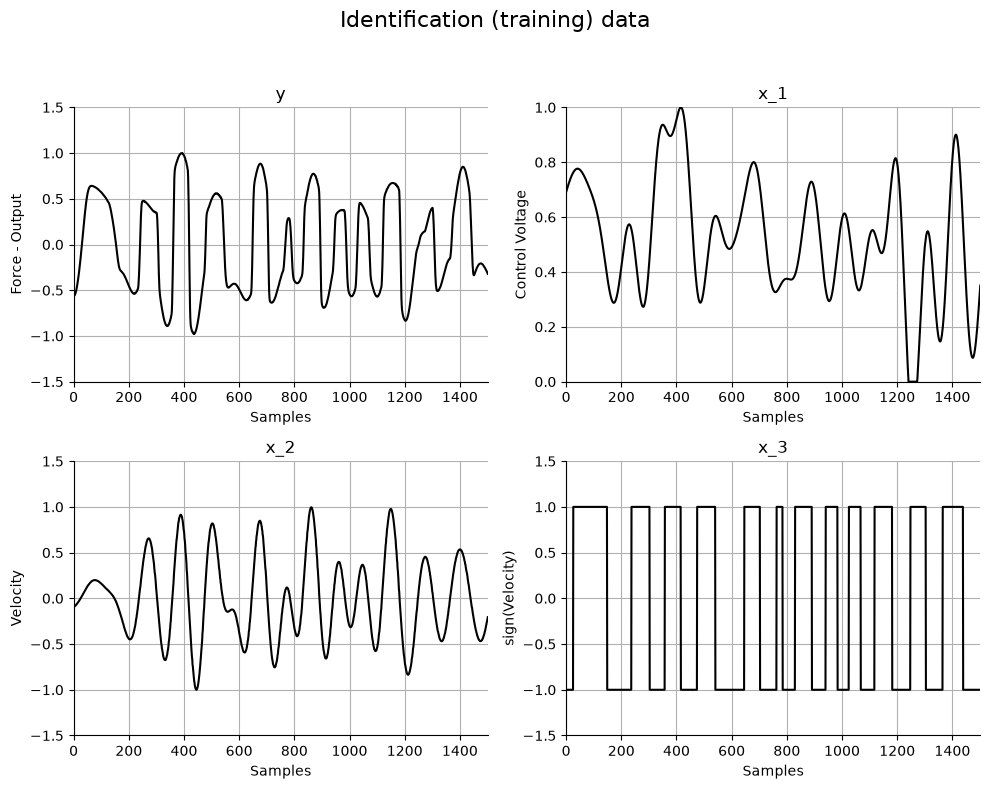

In [1]:
from warnings import catch_warnings, simplefilter
import numpy as np
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt

from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial
from sysidentpy.utils.display_results import results
from sysidentpy.parameter_estimation import LeastSquares
from sysidentpy.metrics import root_relative_squared_error
from sysidentpy.utils.plotting import plot_results

df = pd.read_csv(
    "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/4085901293ba5ed5674bb2911ef4d1fa20f3438d/datasets/bouc_wen/boucwen_histeretic_system.csv"
)
scaler_x = MaxAbsScaler()
scaler_y = MaxAbsScaler()

init = 400
x_train = df[["E", "v"]].iloc[init : df.shape[0] // 2, :]
x_train["sign_v"] = np.sign(df["v"])
x_train = scaler_x.fit_transform(x_train)

x_test = df[["E", "v"]].iloc[df.shape[0] // 2 + 1 : df.shape[0] - init, :]
x_test["sign_v"] = np.sign(df["v"])
x_test = scaler_x.transform(x_test)

y_train = df[["f"]].iloc[init : df.shape[0] // 2, :].values.reshape(-1, 1)
y_train = scaler_y.fit_transform(y_train)

y_test = (
    df[["f"]].iloc[df.shape[0] // 2 + 1 : df.shape[0] - init, :].values.reshape(-1, 1)
)
y_test = scaler_y.transform(y_test)

# Plotting the data
plt.figure(figsize=(10, 8))
plt.suptitle("Identification (training) data", fontsize=16)

plt.subplot(221)
plt.plot(y_train, "k")
plt.ylabel("Force - Output")
plt.xlabel("Samples")
plt.title("y")
plt.grid()
plt.axis([0, 1500, -1.5, 1.5])

plt.subplot(222)
plt.plot(x_train[:, 0], "k")
plt.ylabel("Control Voltage")
plt.xlabel("Samples")
plt.title("x_1")
plt.grid()
plt.axis([0, 1500, 0, 1])

plt.subplot(223)
plt.plot(x_train[:, 1], "k")
plt.ylabel("Velocity")
plt.xlabel("Samples")
plt.title("x_2")
plt.grid()
plt.axis([0, 1500, -1.5, 1.5])

plt.subplot(224)
plt.plot(x_train[:, 2], "k")
plt.ylabel("sign(Velocity)")
plt.xlabel("Samples")
plt.title("x_3")
plt.grid()
plt.axis([0, 1500, -1.5, 1.5])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

The pairwise plots help reveal the multivalued force relation associated with
each candidate input.


Text(0, 0.5, 'y - Force')

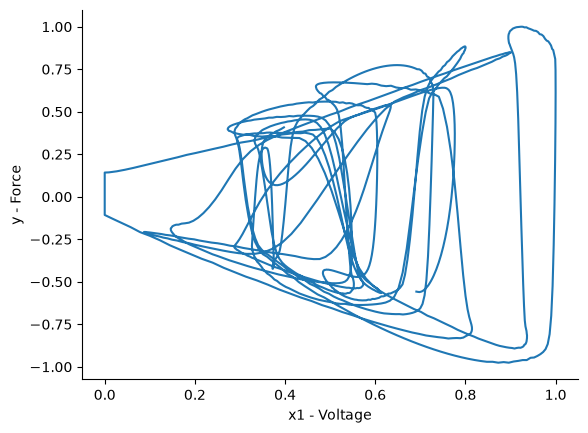

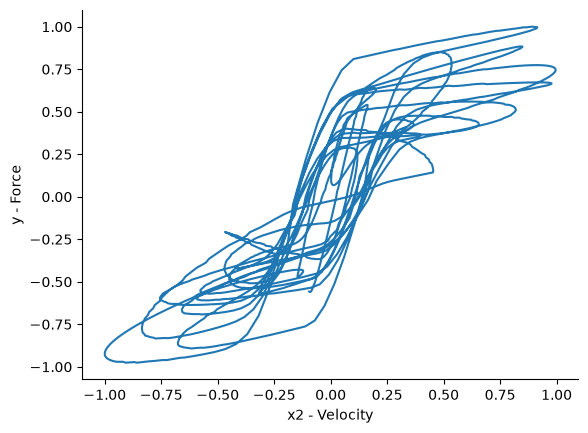

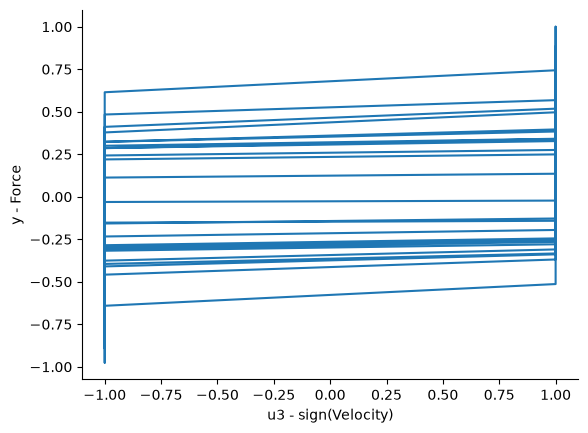

In [2]:
plt.figure()
plt.plot(x_train[:, 0], y_train)
plt.xlabel("x1 - Voltage")
plt.ylabel("y - Force")

plt.figure()
plt.plot(x_train[:, 1], y_train)
plt.xlabel("x2 - Velocity")
plt.ylabel("y - Force")

plt.figure()
plt.plot(x_train[:, 2], y_train)
plt.xlabel("u3 - sign(Velocity)")
plt.ylabel("y - Force")

Now, we can build a NARX model. With all three inputs and `MaxAbsScaler`, the
free-run RRSE is $0.045104$:


0.04510435472905578


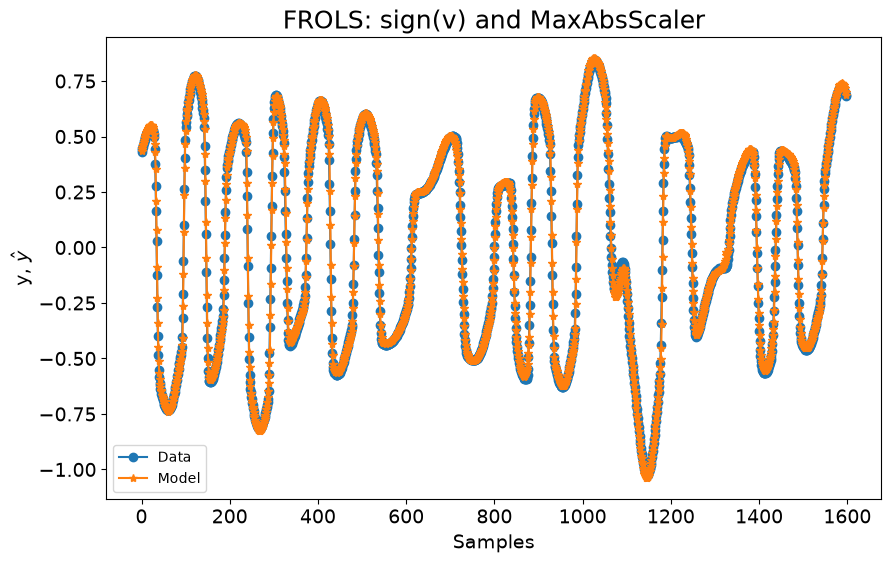

In [3]:
basis_function = Polynomial(degree=3)
model = FROLS(
    xlag=[[1], [1], [1]],
    ylag=1,
    basis_function=basis_function,
    estimator=LeastSquares(),
    info_criteria="aic",
)

model.fit(X=x_train, y=y_train)
yhat = model.predict(X=x_test, y=y_test[: model.max_lag :, :])
rrse = root_relative_squared_error(y_test[model.max_lag :], yhat[model.max_lag :])
print(rrse)
plot_results(
    y=y_test[model.max_lag :],
    yhat=yhat[model.max_lag :],
    n=10000,
    title="FROLS: sign(v) and MaxAbsScaler",
)

If we remove the `sign(v)` input and use the same configuration, free-run
simulation diverges at sample 203, as shown in the following figure:


Free-run simulation diverged at sample 203.


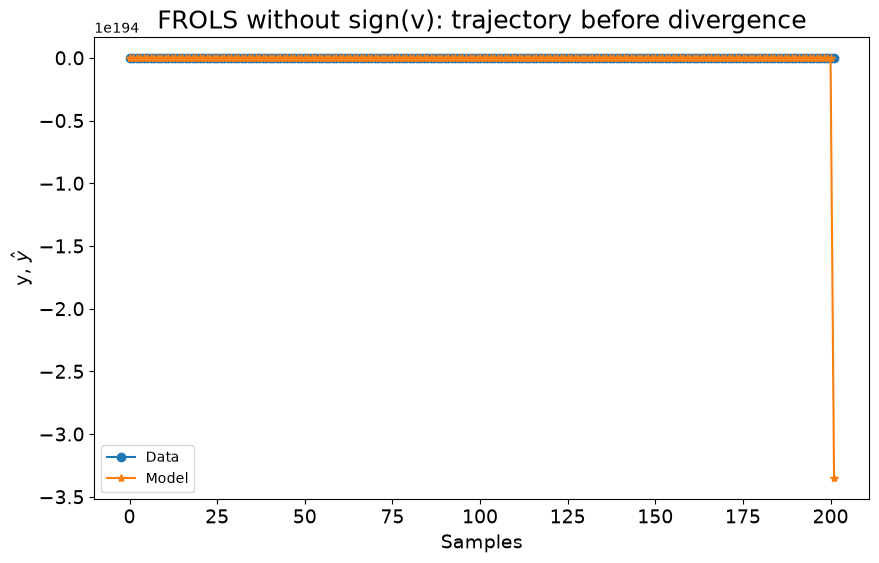

In [4]:
basis_function = Polynomial(degree=3)
model = FROLS(
    xlag=[[1], [1]],
    ylag=1,
    basis_function=basis_function,
    estimator=LeastSquares(),
    info_criteria="aic",
)

model.fit(X=x_train[:, :2], y=y_train)
with catch_warnings(), np.errstate(over="ignore", invalid="ignore"):
    simplefilter("ignore", RuntimeWarning)
    yhat = model.predict(
        X=x_test[:, :2], y=y_test[: model.max_lag]
    )
if np.isfinite(yhat).all():
    rrse = root_relative_squared_error(
        y_test[model.max_lag :], yhat[model.max_lag :]
    )
    print(rrse)
    plot_results(
        y=y_test[model.max_lag :],
        yhat=yhat[model.max_lag :],
        n=10000,
        title="FROLS without sign(v)",
    )
else:
    finite_mask = np.isfinite(yhat[:, 0])
    finite_stop = int(np.flatnonzero(~finite_mask)[0])
    print(f"Free-run simulation diverged at sample {finite_stop}.")
    plot_results(
        y=y_test[model.max_lag : finite_stop],
        yhat=yhat[model.max_lag : finite_stop],
        n=max(1, finite_stop - model.max_lag),
        title="FROLS without sign(v): trajectory before divergence",
    )

Using MetaMSS without `sign(v)` delays the loss of numerical stability, but does
not eliminate it: this free-run trajectory diverges at sample 1153.


Free-run simulation diverged at sample 1153.


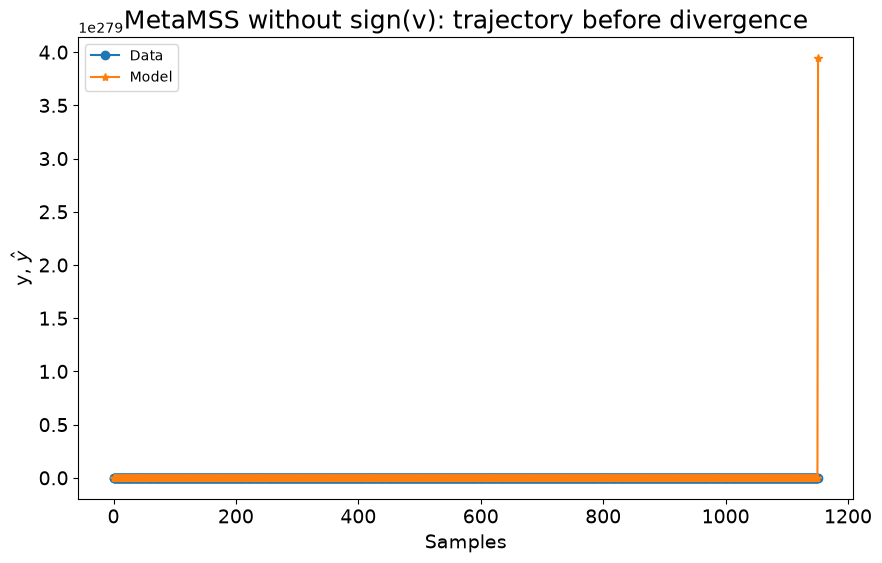

In [5]:
from sysidentpy.model_structure_selection import MetaMSS

basis_function = Polynomial(degree=3)
model = MetaMSS(
    xlag=[[1], [1]],
    ylag=1,
    basis_function=basis_function,
    estimator=LeastSquares(),
    random_state=42,
)

with catch_warnings(), np.errstate(over="ignore", invalid="ignore"):
    simplefilter("ignore", RuntimeWarning)
    simplefilter("ignore", UserWarning)
    model.fit(X=x_train[:, :2], y=y_train)
    yhat = model.predict(
        X=x_test[:, :2], y=y_test[: model.max_lag]
    )
if np.isfinite(yhat).all():
    rrse = root_relative_squared_error(
        y_test[model.max_lag :], yhat[model.max_lag :]
    )
    print(rrse)
    finite_stop = len(yhat)
    plot_results(
        y=y_test[model.max_lag :],
        yhat=yhat[model.max_lag :],
        n=10000,
        title="MetaMSS without sign(v)",
    )
else:
    finite_mask = np.isfinite(yhat[:, 0])
    finite_stop = int(np.flatnonzero(~finite_mask)[0])
    print(f"Free-run simulation diverged at sample {finite_stop}.")
    plot_results(
        y=y_test[model.max_lag : finite_stop],
        yhat=yhat[model.max_lag : finite_stop],
        n=max(1, finite_stop - model.max_lag),
        title="MetaMSS without sign(v): trajectory before divergence",
    )

Before divergence, the oscillatory behavior becomes visible when the output
approaches its minimum value.


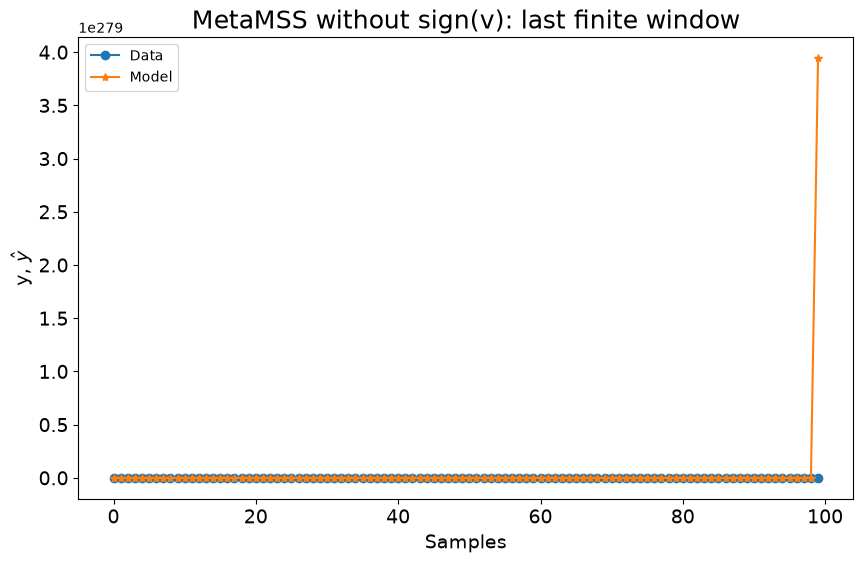

In [6]:
window_stop = finite_stop
window_start = max(model.max_lag, window_stop - 100)
plot_results(
    y=y_test[window_start:window_stop],
    yhat=yhat[window_start:window_stop],
    n=100,
    title="MetaMSS without sign(v): last finite window",
)

If we add the `sign(v)` input again and use MetaMSS, the free-run simulation is
finite and gives RRSE $0.055707$, close to the FROLS result with all inputs.


0.05570709330492503


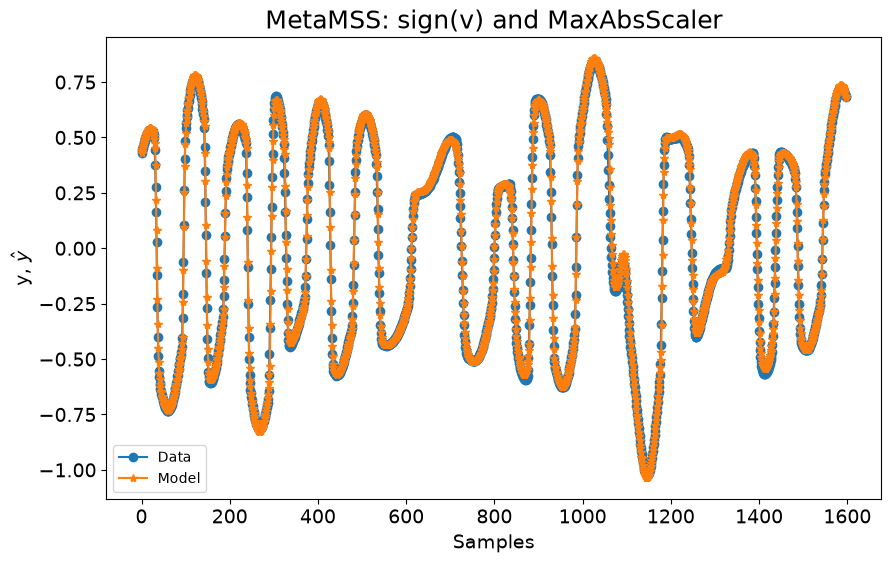

In [7]:
basis_function = Polynomial(degree=3)
model = MetaMSS(
    xlag=[[1], [1], [1]],
    ylag=1,
    basis_function=basis_function,
    estimator=LeastSquares(),
    random_state=42,
)

with catch_warnings(), np.errstate(over="ignore", invalid="ignore"):
    simplefilter("ignore", RuntimeWarning)
    simplefilter("ignore", UserWarning)
    model.fit(X=x_train, y=y_train)
    yhat = model.predict(X=x_test, y=y_test[: model.max_lag :, :])
rrse = root_relative_squared_error(y_test[model.max_lag :], yhat[model.max_lag :])
print(rrse)
plot_results(
    y=y_test[model.max_lag :],
    yhat=yhat[model.max_lag :],
    n=10000,
    title="MetaMSS: sign(v) and MaxAbsScaler",
)

This case will also highlight the significance of data scaling. Previously, we used the `MaxAbsScaler` method, which resulted in great models when using the `sign(v)` inputs, but also resulted in unstable models when removing that input feature. When scaling is applied using `MinMaxScaler`, however, the overall stability of the results improves, and the model does not diverge, even when the `sign(v)` input is removed, using the `FROLS` algorithm.

The user can get the results bellow by just changing the data scaling method using


FROLS with sign(v): RRSE=0.115986


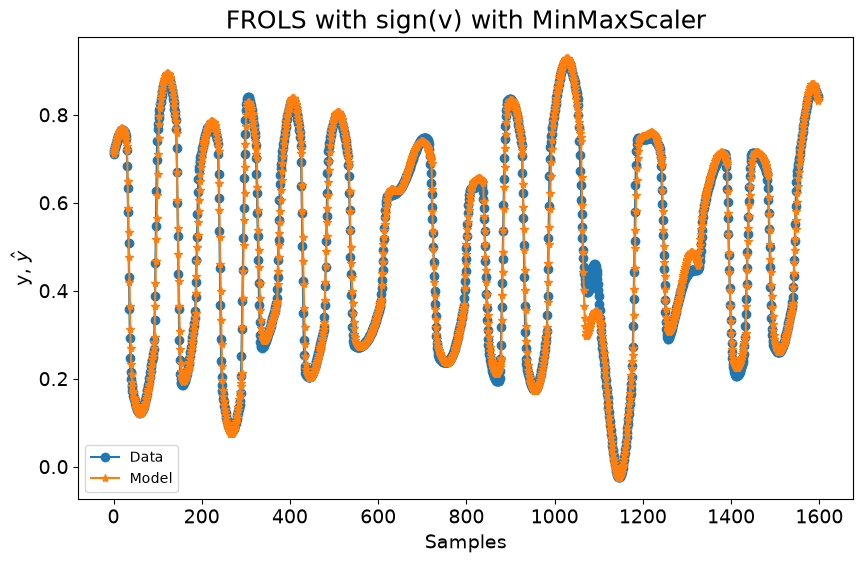

FROLS without sign(v): RRSE=0.163944


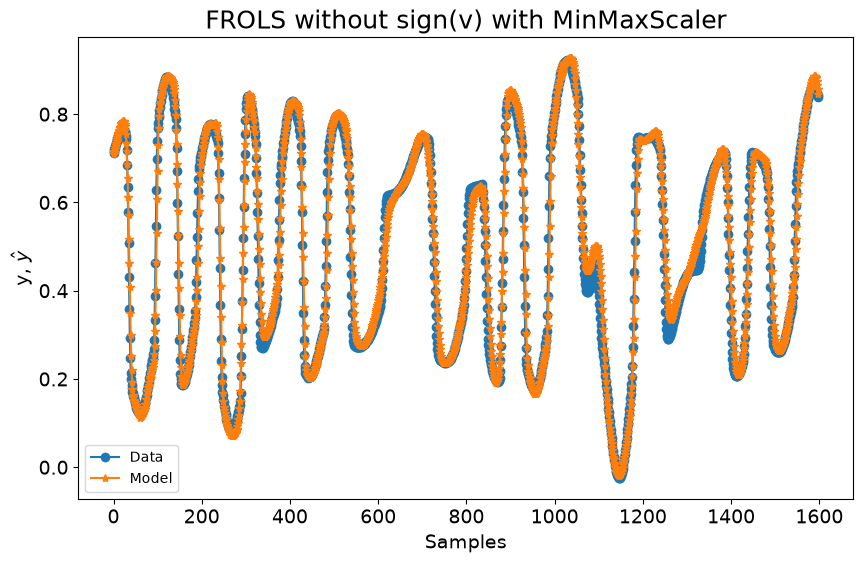

MetaMSS without sign(v): RRSE=0.185607


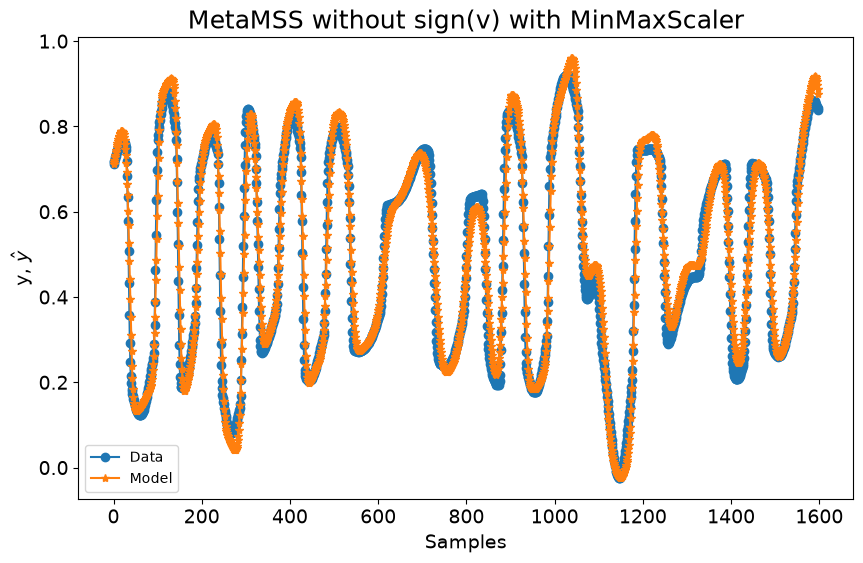

MetaMSS with sign(v): RRSE=0.104511


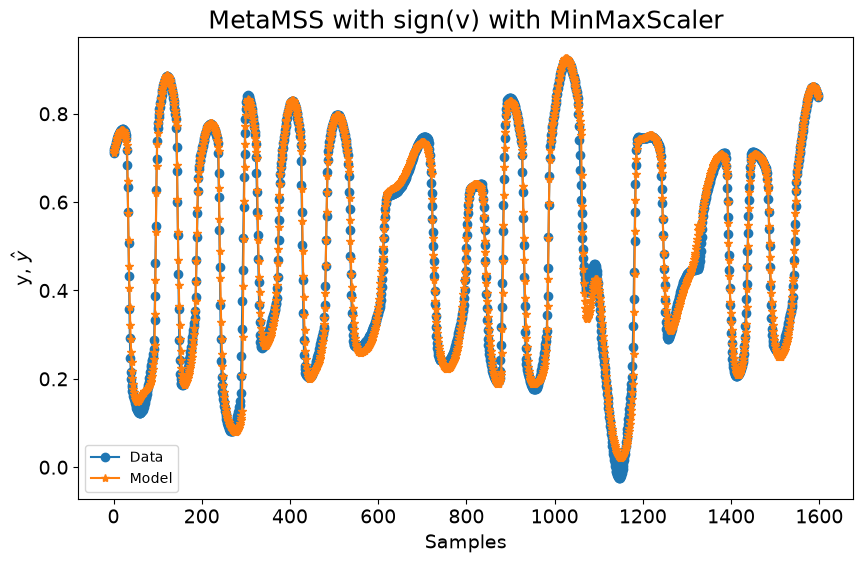

In [8]:
minmax_scaler_x = MinMaxScaler()
minmax_scaler_y = MinMaxScaler()
midpoint = df.shape[0] // 2

x_train_minmax_frame = df[["E", "v"]].iloc[init:midpoint].copy()
x_train_minmax_frame["sign_v"] = np.sign(x_train_minmax_frame["v"])
x_test_minmax_frame = df[["E", "v"]].iloc[midpoint + 1 : df.shape[0] - init].copy()
x_test_minmax_frame["sign_v"] = np.sign(x_test_minmax_frame["v"])
x_train_minmax = minmax_scaler_x.fit_transform(x_train_minmax_frame)
x_test_minmax = minmax_scaler_x.transform(x_test_minmax_frame)

y_train_minmax = minmax_scaler_y.fit_transform(
    df[["f"]].iloc[init:midpoint].to_numpy()
)
y_test_minmax = minmax_scaler_y.transform(
    df[["f"]].iloc[midpoint + 1 : df.shape[0] - init].to_numpy()
)

def run_minmax_experiment(name, selector, use_sign):
    n_inputs = 3 if use_sign else 2
    x_train_variant = x_train_minmax[:, :n_inputs]
    x_test_variant = x_test_minmax[:, :n_inputs]
    if selector == "FROLS":
        candidate = FROLS(
            xlag=[[1]] * n_inputs,
            ylag=1,
            basis_function=Polynomial(degree=3),
            estimator=LeastSquares(),
            info_criteria="aic",
        )
    else:
        candidate = MetaMSS(
            xlag=[[1]] * n_inputs,
            ylag=1,
            basis_function=Polynomial(degree=3),
            estimator=LeastSquares(),
            random_state=42,
        )

    with catch_warnings(), np.errstate(over="ignore", invalid="ignore"):
        simplefilter("ignore", RuntimeWarning)
        simplefilter("ignore", UserWarning)
        candidate.fit(X=x_train_variant, y=y_train_minmax)
        prediction = candidate.predict(
            X=x_test_variant,
            y=y_test_minmax[: candidate.max_lag],
        )

    finite_mask = np.isfinite(prediction[:, 0])
    if finite_mask.all():
        score = root_relative_squared_error(
            y_test_minmax[candidate.max_lag :],
            prediction[candidate.max_lag :],
        )
        print(f"{name}: RRSE={score:.6f}")
        stop = len(prediction)
    else:
        score = np.nan
        stop = int(np.flatnonzero(~finite_mask)[0])
        print(f"{name}: free-run simulation diverged at sample {stop}")

    plot_results(
        y=y_test_minmax[candidate.max_lag : stop],
        yhat=prediction[candidate.max_lag : stop],
        n=max(1, stop - candidate.max_lag),
        title=f"{name} with MinMaxScaler",
    )
    return prediction, score

minmax_results = {
    "FROLS with sign(v)": run_minmax_experiment(
        "FROLS with sign(v)", "FROLS", True
    ),
    "FROLS without sign(v)": run_minmax_experiment(
        "FROLS without sign(v)", "FROLS", False
    ),
    "MetaMSS without sign(v)": run_minmax_experiment(
        "MetaMSS without sign(v)", "MetaMSS", False
    ),
    "MetaMSS with sign(v)": run_minmax_experiment(
        "MetaMSS with sign(v)", "MetaMSS", True
    ),
}
yhat = minmax_results["MetaMSS with sign(v)"][0]
x_test = x_test_minmax
y_test = y_test_minmax

and running each model again. This change makes every free-run trajectory finite,
but it does not improve the complete-input configurations.

> FROLS with `sign(v)` and `MinMaxScaler`: RRSE 0.115986.

> FROLS without `sign(v)` and using `MinMaxScaler`: RRSE 0.163944.

> MetaMSS without `sign(v)` and using `MinMaxScaler`: RRSE 0.185607.

> MetaMSS with `sign(v)` and using `MinMaxScaler`: RRSE 0.104511.

The complete comparison is:

| Scaling | Selector | Inputs | Free-run result |
| --- | --- | --- | ---: |
| MaxAbs | FROLS | with `sign(v)` | RRSE 0.045104 |
| MaxAbs | FROLS | without `sign(v)` | diverged at sample 203 |
| MaxAbs | MetaMSS | without `sign(v)` | diverged at sample 1153 |
| MaxAbs | MetaMSS | with `sign(v)` | RRSE 0.055707 |
| MinMax | FROLS | with `sign(v)` | RRSE 0.115986 |
| MinMax | FROLS | without `sign(v)` | RRSE 0.163944 |
| MinMax | MetaMSS | without `sign(v)` | RRSE 0.185607 |
| MinMax | MetaMSS | with `sign(v)` | RRSE 0.104511 |

MetaMSS with `sign(v)` is the best of the MinMax-scaled configurations. The
best result overall remains FROLS with `sign(v)` and `MaxAbsScaler`. A non-finite
free-run output is reported as divergence rather than converted into a scalar
metric.

Here is the predicted hysteretic loop:


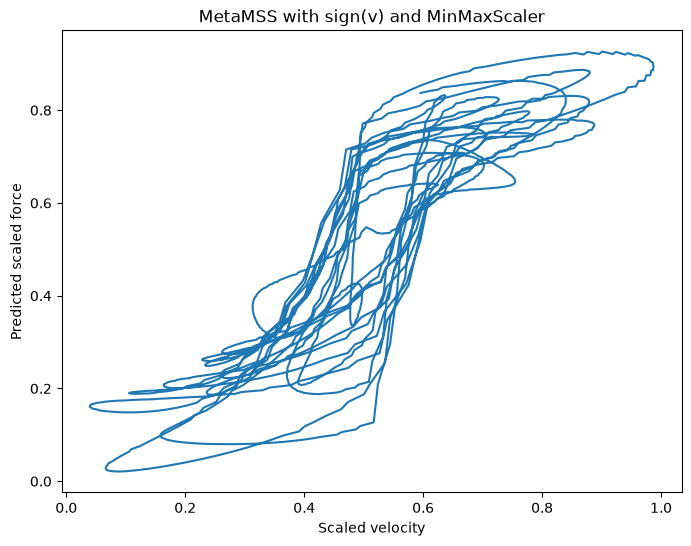

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(x_test[:, 1], yhat)
plt.xlabel("Scaled velocity")
plt.ylabel("Predicted scaled force")
plt.title("MetaMSS with sign(v) and MinMaxScaler")
plt.show()